# Importación de Librerías

In [1]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model

# Rutas

In [2]:
BASE_DIR     = 'chest_xray'
BASE_MASKED  = 'chest_xray_masked'
MODEL_PATH   = os.path.join('Modelos', 'model.h5')

TRAIN_DIR    = os.path.join(BASE_DIR, 'train')
VAL_DIR      = os.path.join(BASE_DIR, 'val')
TEST_DIR     = os.path.join(BASE_DIR, 'test')

TRAIN_MASKED = os.path.join(BASE_MASKED, 'train')
VAL_MASKED   = os.path.join(BASE_MASKED, 'val')
TEST_MASKED  = os.path.join(BASE_MASKED, 'test')

CLASSES = ['NORMAL', 'PNEUMONIA']

# Modelo U-NET

## Cargar modelo U-Net preentrenado

https://github.com/rani700/xray 

In [3]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detectadas: {len(gpus)}")
if len(gpus) > 0:
    for gpu in gpus:
        print("Detalles:", gpu)
else:
    print("TensorFlow solo está usando la CPU.")

GPUs detectadas: 0
TensorFlow solo está usando la CPU.


In [4]:
seg_model = load_model(MODEL_PATH, compile=False)
print(f"  Input shape  : {seg_model.input_shape}")
print(f"  Output shape : {seg_model.output_shape}")

# Guardar el tamaño que espera el modelo
input_shape = seg_model.input_shape
MODEL_H = input_shape[1]
MODEL_W = input_shape[2]
MODEL_C = input_shape[3]

print(f"\n  El modelo espera imágenes de {MODEL_H}×{MODEL_W} con {MODEL_C} canal(es)")

  Input shape  : (None, 512, 512, 1)
  Output shape : (None, 512, 512, 1)

  El modelo espera imágenes de 512×512 con 1 canal(es)


##  Funciones de segmentación

Funciones de generación y aplicación de máscara

In [5]:
def generar_mascara(img_path, seg_model, model_h, model_w, model_c,
                     threshold=0.5):
    """
    Genera máscara binaria pulmonar con el modelo U-Net.
    Se adapta automáticamente al input shape del modelo.
    """
    # Cargar imagen original
    img_orig = np.array(Image.open(img_path).convert('RGB'))
    orig_h, orig_w = img_orig.shape[:2]

    # Preparar input según canales que espera el modelo
    if model_c == 1:
        img_gray    = cv2.cvtColor(img_orig, cv2.COLOR_RGB2GRAY)
        img_resized = cv2.resize(img_gray, (model_w, model_h))
        img_input   = img_resized.astype(np.float32) / 255.0
        img_input   = img_input.reshape(1, model_h, model_w, 1)
    else:
        img_resized = cv2.resize(img_orig, (model_w, model_h))
        img_input   = img_resized.astype(np.float32) / 255.0
        img_input   = img_input.reshape(1, model_h, model_w, model_c)
        
    pred = seg_model(img_input, training=False).numpy()
    # Extraer máscara 2D
    if pred.ndim == 4:
        mask_pred = pred[0, :, :, 0]
    elif pred.ndim == 3:
        mask_pred = pred[0]
    else:
        mask_pred = pred

    # Umbralizar
    mask_bin = (mask_pred > threshold).astype(np.uint8)

    # Operaciones morfológicas
    kernel   = np.ones((10, 10), np.uint8)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN,  kernel)

    # Redimensionar a resolución original
    mask_orig = cv2.resize(mask_bin, (orig_w, orig_h),
                           interpolation=cv2.INTER_NEAREST)
    return mask_orig

def aplicar_mascara_y_guardar(img_path, output_path, seg_model,
                               model_h, model_w, model_c,
                               target_size=(224, 224), threshold=0.5):
    """
    Carga imagen, genera máscara, aplica y guarda resultado.
    """
    img_rgb = np.array(Image.open(img_path).convert('RGB'))

    # Generar máscara
    mask = generar_mascara(img_path, seg_model, model_h, model_w, model_c,
                           threshold)

    # Aplicar — fuera del pulmón → negro
    mask_3ch   = np.stack([mask] * 3, axis=-1)
    img_masked = img_rgb * mask_3ch

    # Redimensionar y guardar
    img_final = cv2.resize(img_masked, target_size,
                           interpolation=cv2.INTER_LINEAR)
    Image.fromarray(img_final.astype(np.uint8)).save(output_path)
    return img_final, mask


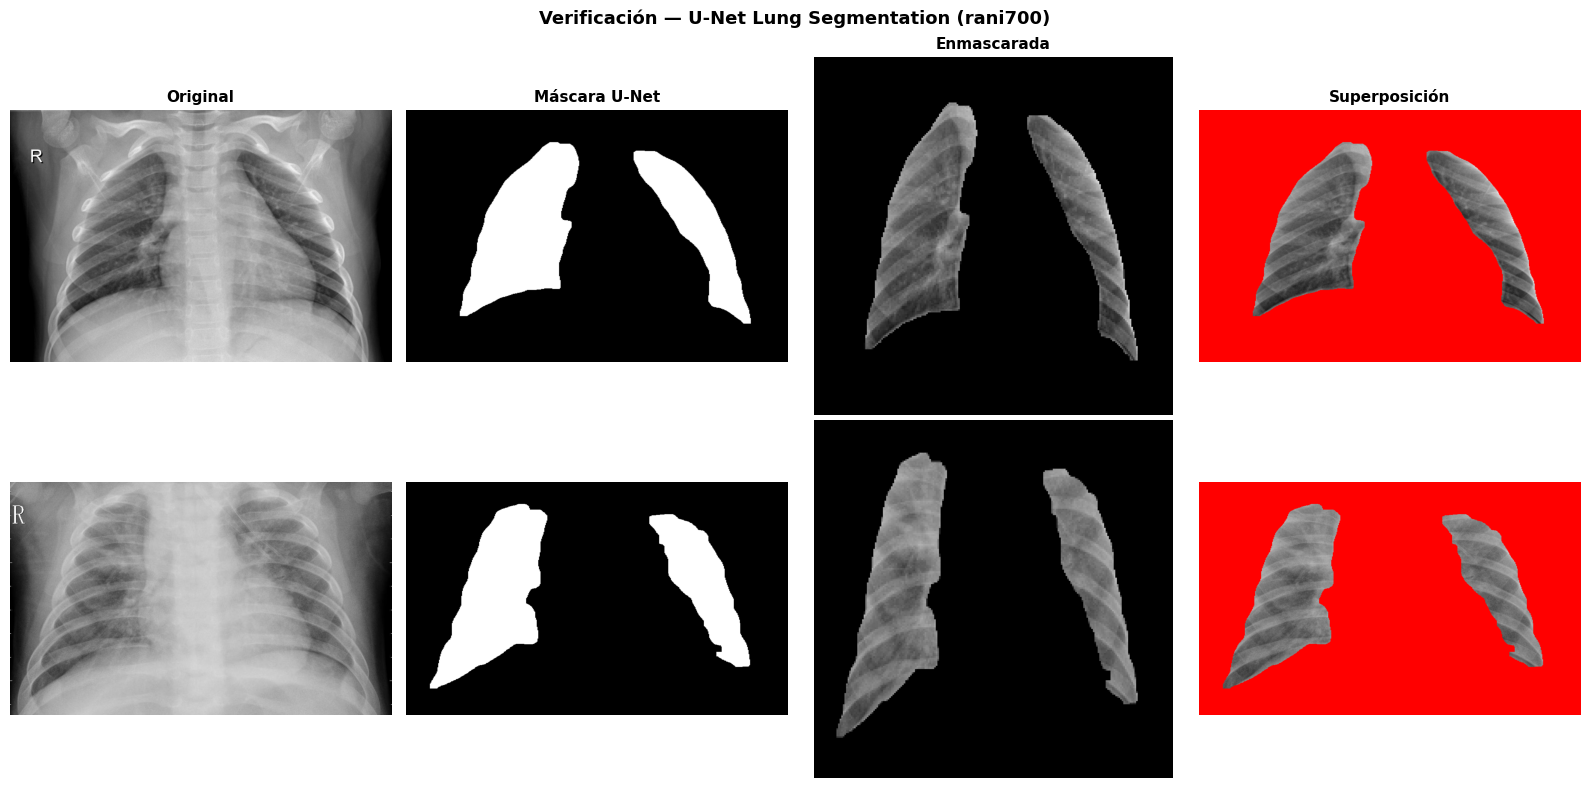

In [ ]:
# Verificación visual
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
col_titles = ['Original', 'Máscara U-Net', 'Enmascarada', 'Superposición']

for fila, clase in enumerate(CLASSES):
    ruta_clase = os.path.join(TRAIN_DIR, clase)
    archivos   = sorted([f for f in os.listdir(ruta_clase)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    img_path   = os.path.join(ruta_clase, archivos[5])

    img_orig = np.array(Image.open(img_path).convert('RGB'))
    img_masked, mask = aplicar_mascara_y_guardar(
        img_path, '_temp.jpg', seg_model,
        MODEL_H, MODEL_W, MODEL_C
    )

    # Superposición — zona excluida en rojo
    mask_vis = cv2.resize(mask, (img_orig.shape[1], img_orig.shape[0]),
                          interpolation=cv2.INTER_NEAREST)
    superposicion = img_orig.copy()
    superposicion[mask_vis == 0] = [255, 0, 0]

    imagenes = [img_orig, mask_vis * 255, img_masked, superposicion]
    for col, img in enumerate(imagenes):
        axes[fila][col].imshow(img, cmap='gray' if col == 1 else None)
        axes[fila][col].axis('off')
        if fila == 0:
            axes[fila][col].set_title(col_titles[col], fontsize=11,
                                      fontweight='bold')
        if col == 0:
            axes[fila][col].set_ylabel(
                clase, fontsize=11, fontweight='bold',
                color='#E05C5C' if clase == 'PNEUMONIA' else '#4A90D9'
            )

plt.suptitle('Verificación — U-Net Lung Segmentation (rani700)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('verificacion_unet.png', dpi=150, bbox_inches='tight')
plt.show()

## Procesar Dataset completo

In [6]:
def procesar_split(split_dir, output_dir, seg_model,
                   model_h, model_w, model_c, clases=CLASSES):
    total_ok  = 0
    total_err = 0
    total_saltados = 0 
    t_start   = time.time()

    for clase in clases:
        input_clase  = os.path.join(split_dir, clase)
        output_clase = os.path.join(output_dir, clase)
        os.makedirs(output_clase, exist_ok=True)

        archivos = sorted([
            f for f in os.listdir(input_clase)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"  Procesando {clase}: {len(archivos)} imágenes...")

        for i, archivo in enumerate(archivos):
            out_path = os.path.join(output_clase, archivo)
            
            # NUEVO: Si el archivo ya existe en la carpeta de destino, lo saltamos
            if os.path.exists(out_path):
                total_saltados += 1
                continue

            try:
                img_path = os.path.join(input_clase, archivo)
                aplicar_mascara_y_guardar(
                    img_path, out_path, seg_model,
                    model_h, model_w, model_c
                )
                total_ok += 1
                if (i + 1) % 100 == 0:
                    elapsed = time.time() - t_start
                    print(f"    → {i+1}/{len(archivos)} | {elapsed/60:.1f} min")
            except Exception as e:
                print(f"    Error en {archivo}: {e}")
                total_err += 1

    elapsed = time.time() - t_start
    print(f"  ✓ {total_ok} procesados, {total_saltados} saltados (ya existían), {total_err} errores — {elapsed/60:.1f} min\n")

print("=" * 50)
print("  PROCESANDO DATASET COMPLETO")
print("=" * 50)

print("\nProcesando TRAIN...")
procesar_split(TRAIN_DIR, TRAIN_MASKED, seg_model, MODEL_H, MODEL_W, MODEL_C)

print("Procesando VAL...")
procesar_split(VAL_DIR, VAL_MASKED, seg_model, MODEL_H, MODEL_W, MODEL_C)

print("Procesando TEST...")
procesar_split(TEST_DIR, TEST_MASKED, seg_model, MODEL_H, MODEL_W, MODEL_C)

print("=" * 50)
print(f" DATASET ENMASCARADO COMPLETO")
print(f"  Guardado en: {os.path.abspath(BASE_MASKED)}")
print("=" * 50)

  PROCESANDO DATASET COMPLETO

Procesando TRAIN...
  Procesando NORMAL: 1341 imágenes...


c:\Users\Wang Jin\miniconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_2']
Received: inputs=Tensor(shape=(1, 512, 512, 1))
  warnings.warn(msg)


    → 200/1341 | 3.9 min
    → 300/1341 | 35.7 min
    → 400/1341 | 67.2 min
    → 500/1341 | 99.0 min
    → 600/1341 | 131.2 min
    → 700/1341 | 163.3 min
    → 800/1341 | 195.1 min
    → 900/1341 | 227.2 min
    → 1000/1341 | 259.0 min
    → 1100/1341 | 291.2 min
    → 1200/1341 | 323.1 min
    → 1300/1341 | 355.2 min
  Procesando PNEUMONIA: 3875 imágenes...
    → 100/3875 | 400.6 min
    → 200/3875 | 434.6 min
    → 300/3875 | 468.8 min
    → 400/3875 | 502.9 min
    → 500/3875 | 537.1 min
    → 600/3875 | 571.3 min
    → 700/3875 | 605.5 min
    → 800/3875 | 640.0 min
    → 900/3875 | 674.6 min
    → 1000/3875 | 709.4 min
    → 1100/3875 | 744.2 min
    → 1200/3875 | 778.6 min
    → 1300/3875 | 812.5 min
    → 1400/3875 | 847.3 min
    → 1500/3875 | 882.1 min
    → 1600/3875 | 914.4 min
    → 1700/3875 | 946.0 min
    → 1800/3875 | 977.6 min
    → 1900/3875 | 1009.3 min
    → 2000/3875 | 1041.2 min
    → 2100/3875 | 1073.0 min
    → 2200/3875 | 1105.2 min
    → 2300/3875 | 1137.3 